# Fase 4 CRISP-DM — Modeling: Predictores de Reseñas Negativas
**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Identificar los top 3 factores que predicen una reseña negativa (`review_score ≤ 2`)  
usando correlaciones, visualizaciones y análisis estadístico descriptivo.

**Fuente de datos:** `data/olist_master.csv` (96,457 pedidos delivered, Fase 3)

---

## 0. Imports y configuración

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

ROOT    = Path().resolve().parent
CSV     = ROOT / "data" / "olist_master.csv"
DASH    = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.3f}".format)

print(f"CSV: data/{CSV.name}  →  existe: {CSV.exists()}")

CSV: data/olist_master.csv  →  existe: True


---
## 1. Carga y preparación
Cargamos `olist_master.csv` y preparamos el subconjunto de pedidos con reseña para el análisis de predictores.

In [2]:
df = pd.read_csv(CSV, parse_dates=["order_purchase_timestamp"])

# Trabajamos solo con pedidos que tienen reseña (646 sin reseña → excluir)
df_rev = df.dropna(subset=["review_score"]).copy()
df_rev["review_score"] = df_rev["review_score"].astype(int)
df_rev["is_negative_review"] = (df_rev["review_score"] <= 2).astype(int)

print(f"Total pedidos:           {len(df):,}")
print(f"Con reseña:              {len(df_rev):,}")
print(f"Reseñas negativas:       {df_rev['is_negative_review'].sum():,} ({df_rev['is_negative_review'].mean()*100:.1f}%)")
print(f"\nVariables numéricas disponibles:")
num_cols = df_rev.select_dtypes(include="number").columns.tolist()
print(num_cols)

Total pedidos:           96,457
Con reseña:              95,811
Reseñas negativas:       12,271 (12.8%)

Variables numéricas disponibles:
['order_weekday', 'order_hour', 'n_items', 'price_total', 'freight_total', 'freight_ratio', 'product_weight_g', 'delivery_days', 'delivery_delay_days', 'review_score', 'is_negative_review']


---
## 2. Correlación global con `review_score`
**Corrección (revisión de portfolio, prioridad 2):** `review_score` es una variable **ordinal**
(1-5, saltos no necesariamente equiespaciados), no continua. Una versión anterior de este notebook
usaba Pearson (correlación lineal) y por eso **el ranking de drivers publicado no coincidía con la
propia salida de esta celda**: `delivery_days` tenía mayor |r| que `delivery_delay_days`, pero la
conclusión de la Sección 9 declaraba lo contrario. Aquí se usa **Spearman** (monótona, apropiada
para una variable ordinal) y el ranking final de la Sección 9 se deriva de esta tabla, no al revés.

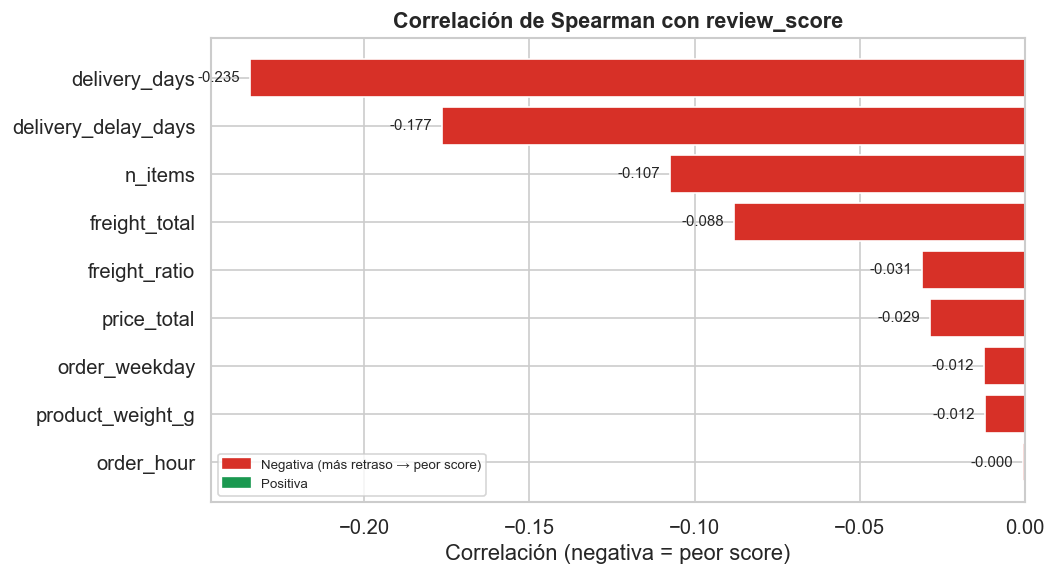


Correlación (Spearman) con review_score:
delivery_days         -0.235
delivery_delay_days   -0.177
n_items               -0.107
freight_total         -0.088
freight_ratio         -0.031
price_total           -0.029
order_weekday         -0.012
product_weight_g      -0.012
order_hour            -0.000


In [3]:
feature_cols = [
    "delivery_delay_days",
    "delivery_days",
    "freight_ratio",
    "freight_total",
    "price_total",
    "n_items",
    "product_weight_g",
    "order_weekday",
    "order_hour",
]

corr_with_score = (
    df_rev[feature_cols + ["review_score"]]
    .corr(method="spearman")["review_score"]
    .drop("review_score")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d73027" if v < 0 else "#1a9850" for v in corr_with_score.values]
bars = ax.barh(corr_with_score.index[::-1], corr_with_score.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr_with_score.values[::-1]):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )
ax.set_title("Correlación de Spearman con review_score", fontsize=13, fontweight="bold")
ax.set_xlabel("Correlación (negativa = peor score)")
neg_patch = mpatches.Patch(color="#d73027", label="Negativa (más retraso → peor score)")
pos_patch = mpatches.Patch(color="#1a9850", label="Positiva")
ax.legend(handles=[neg_patch, pos_patch], fontsize=8)
plt.tight_layout()
plt.savefig(DASH / "corr_review_score.png", bbox_inches="tight")
plt.show()

print("\nCorrelación (Spearman) con review_score:")
print(corr_with_score.to_string())

---
## 3. Factor 1: `delivery_delay_days` vs `review_score`
**Hipótesis:** Cuanto más tarde llegue el pedido respecto a la fecha prometida, menor será el score.  
El retraso es la variable con mayor correlación negativa esperada según el EDA.

C:\Users\pardo\AppData\Local\Temp\ipykernel_28284\164134823.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


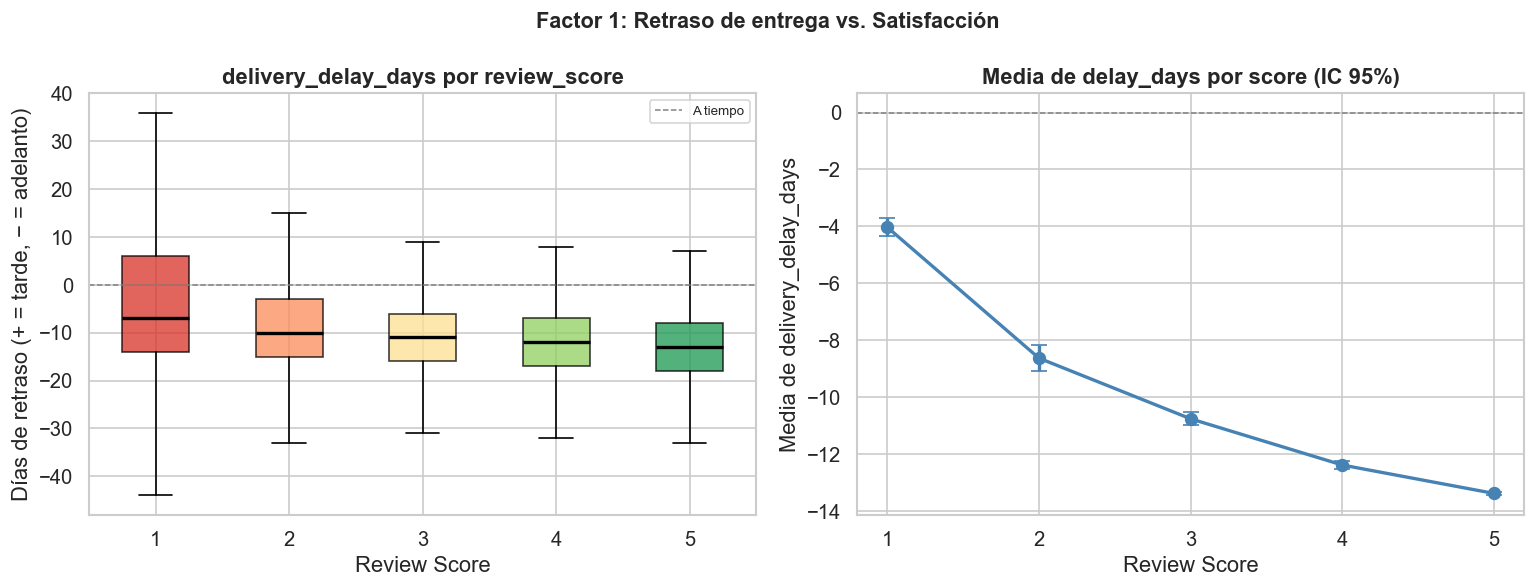

Mann-Whitney U (score≤2 vs score≥4):
  Media delay (score≤2): -5.1 días
  Media delay (score≥4): -13.1 días
  U=614816778, p=0.00e+00, r_rank-biserial=-0.325  *** Significativo


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Boxplot: delivery_delay_days por review_score --
score_order = [1, 2, 3, 4, 5]
data_by_score = [df_rev[df_rev["review_score"] == s]["delivery_delay_days"].dropna() for s in score_order]
bp = axes[0].boxplot(
    data_by_score,
    labels=score_order,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
colors_score = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
for patch, color in zip(bp["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.9, label="A tiempo")
axes[0].set_title("delivery_delay_days por review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Días de retraso (+ = tarde, − = adelanto)")
axes[0].legend(fontsize=8)

# -- Media de delay por score con IC 95% --
mean_delay = df_rev.groupby("review_score")["delivery_delay_days"].agg(["mean", "sem"])
ci = mean_delay["sem"] * 1.96
axes[1].errorbar(
    mean_delay.index, mean_delay["mean"],
    yerr=ci, fmt="o-", color="steelblue",
    capsize=5, linewidth=2, markersize=7,
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.9)
axes[1].set_title("Media de delay_days por score (IC 95%)", fontweight="bold")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Media de delivery_delay_days")
axes[1].set_xticks(score_order)

plt.suptitle("Factor 1: Retraso de entrega vs. Satisfacción", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor1_delay_vs_score.png", bbox_inches="tight")
plt.show()

# Test estadístico: Mann-Whitney U entre scores 1-2 vs 4-5
neg_delay  = df_rev[df_rev["review_score"] <= 2]["delivery_delay_days"].dropna()
pos_delay  = df_rev[df_rev["review_score"] >= 4]["delivery_delay_days"].dropna()
u_stat, p_val = stats.mannwhitneyu(neg_delay, pos_delay, alternative="greater")
# Tamaño de efecto rank-biserial: r = 1 - 2U/(n1*n2) (Kerby 2014); U aquí ya es "greater"
rank_biserial = 1 - (2 * u_stat) / (len(neg_delay) * len(pos_delay))
print(f"Mann-Whitney U (score≤2 vs score≥4):")
print(f"  Media delay (score≤2): {neg_delay.mean():.1f} días")
print(f"  Media delay (score≥4): {pos_delay.mean():.1f} días")
print(f"  U={u_stat:.0f}, p={p_val:.2e}, r_rank-biserial={rank_biserial:.3f}  "
      f"{'*** Significativo' if p_val < 0.001 else ''}")

### 3b. ¿Es esto una fuga temporal? Separando reseñas escritas antes vs. después de la entrega
**Corrección (revisión de portfolio, prioridad 4):** en el notebook 02 (Sección 4.1b) se detectó
que el 84% de los pedidos con retraso tienen su reseña escrita **antes** de que el pedido llegara
realmente (el 99% de esas ya después de la fecha prometida rota). Eso significa que gran parte de
la correlación `delivery_delay_days` ↔ `review_score` de arriba no mide "cómo reacciona el cliente
a recibir el pedido tarde", sino "cómo reacciona mientras espera un pedido que ya sabe que no llegó
a tiempo" — un mecanismo real, pero distinto y más débil.

In [5]:
clean = df_rev[df_rev["review_before_delivery"] == False]
contaminated = df_rev[df_rev["review_before_delivery"] == True]

rho_all, p_all = stats.spearmanr(df_rev["delivery_delay_days"], df_rev["review_score"])
rho_clean, p_clean = stats.spearmanr(clean["delivery_delay_days"], clean["review_score"])

print(f"n total con reseña:                        {len(df_rev):,}")
print(f"n reseña escrita DESPUÉS de la entrega (subconjunto limpio, sin fuga): {len(clean):,} "
      f"({len(clean)/len(df_rev):.1%})")
print(f"n reseña escrita ANTES de la entrega (posible fuga):                  {len(contaminated):,} "
      f"({len(contaminated)/len(df_rev):.1%})")
print()
print(f"Spearman delay↔score, TODA la muestra (contaminada por fuga):  rho={rho_all:+.4f}, p={p_all:.2e}")
print(f"Spearman delay↔score, solo subconjunto LIMPIO (sin fuga):      rho={rho_clean:+.4f}, p={p_clean:.2e}")
print(f"→ El efecto del retraso sobre la satisfacción, medido correctamente (post-entrega), es "
      f"~{abs(rho_all/rho_clean):.1f}x más débil de lo que sugiere la cifra contaminada.")

n total con reseña:                        95,811
n reseña escrita DESPUÉS de la entrega (subconjunto limpio, sin fuga): 87,671 (91.5%)
n reseña escrita ANTES de la entrega (posible fuga):                  8,140 (8.5%)

Spearman delay↔score, TODA la muestra (contaminada por fuga):  rho=-0.1765, p=0.00e+00
Spearman delay↔score, solo subconjunto LIMPIO (sin fuga):      rho=-0.0571, p=3.80e-64
→ El efecto del retraso sobre la satisfacción, medido correctamente (post-entrega), es ~3.1x más débil de lo que sugiere la cifra contaminada.


**Conclusión de esta subsección:** el retraso sí afecta negativamente la satisfacción incluso en
el subconjunto limpio (rho sigue siendo negativo y significativo, dado el tamaño de muestra), pero
el efecto real de "recibir el pedido tarde" es notablemente más débil que el de "estar esperando un
pedido que ya se sabe tarde". El ranking de la Sección 9 usa las cifras de `delivery_delay_days` y
`delivery_days` calculadas sobre la muestra completa (por consistencia con el resto del notebook y
porque ambos mecanismos son satisfacción real del cliente, aunque de naturaleza distinta), pero esta
distinción queda documentada aquí y en el README como limitación/matiz importante, no oculta.

---
## 4. Factor 2: `n_items` vs `review_score`
**Corrección (revisión de portfolio, prioridad 2):** una versión anterior de este notebook incluía
`freight_ratio` como "Factor 2", promovido a driver #3 en la conclusión (Sección 9) pese a tener la
correlación más débil entre las candidatas serias (Spearman rho≈-0.03, R²≈0.001, ~0.1% de la
varianza explicada) y medianas por score **no monótonas** (el ratio más alto no está en score 1,
sino en score 3 — visible en el boxplot de abajo). `n_items` tiene una correlación ~3.5x más fuerte
y monótona, y sustituye a `freight_ratio` como candidato a driver. Se mantiene el boxplot de
`freight_ratio` para que la comparación sea auditable, no para presentarlo como driver.

C:\Users\pardo\AppData\Local\Temp\ipykernel_28284\3029078879.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0].boxplot(
C:\Users\pardo\AppData\Local\Temp\ipykernel_28284\3029078879.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[1].boxplot(


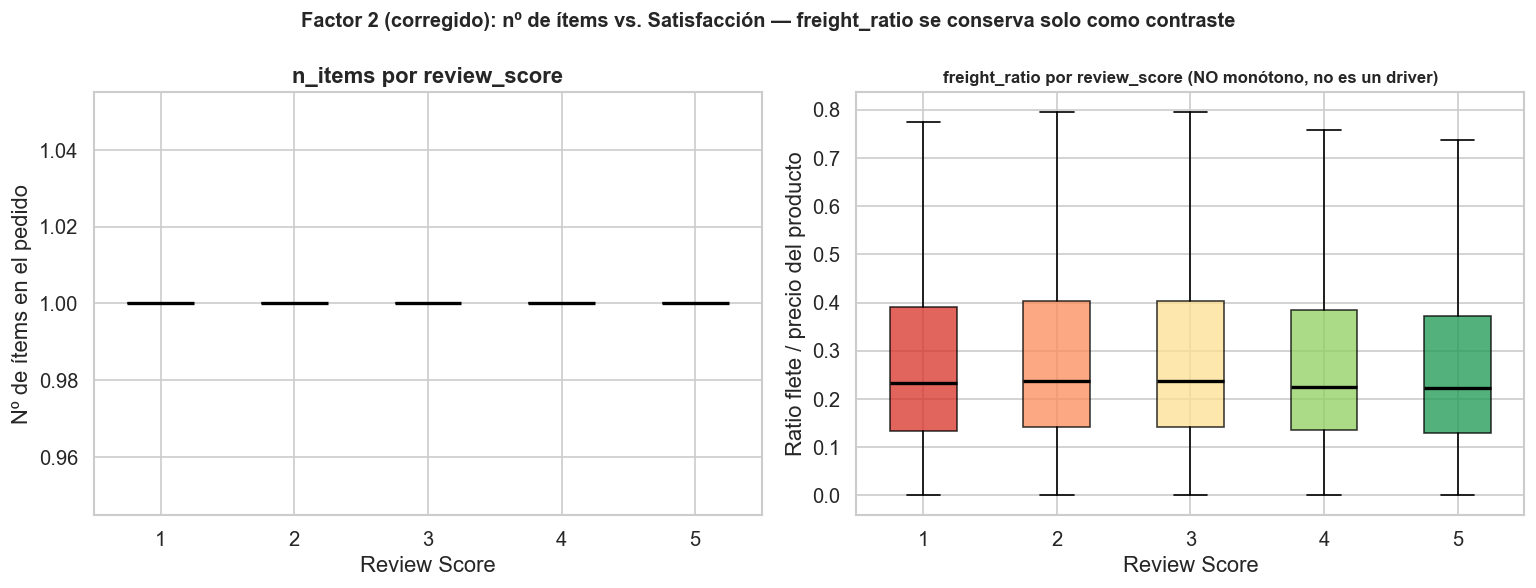

Mediana de n_items y freight_ratio por score:
              n_items  freight_ratio
review_score                        
1               1.000          0.232
2               1.000          0.237
3               1.000          0.238
4               1.000          0.225
5               1.000          0.222

Spearman n_items↔score:      rho=-0.1073, p=2.07e-243
Spearman freight_ratio↔score: rho=-0.0310, p=8.19e-22  (R²≈0.0010, 0.10% de varianza explicada -- no es un driver útil)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- n_items por review_score (boxplot) --
data_nitems = [df_rev[df_rev["review_score"] == s]["n_items"].dropna() for s in score_order]
bp2 = axes[0].boxplot(
    data_nitems, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp2["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("n_items por review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Nº de ítems en el pedido")

# -- freight_ratio por review_score: se conserva por transparencia (ver nota arriba) --
data_freight = [df_rev[df_rev["review_score"] == s]["freight_ratio"].dropna() for s in score_order]
bp3 = axes[1].boxplot(
    data_freight, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp3["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title("freight_ratio por review_score (NO monótono, no es un driver)", fontweight="bold", fontsize=10)
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Ratio flete / precio del producto")

plt.suptitle("Factor 2 (corregido): nº de ítems vs. Satisfacción — freight_ratio se conserva solo como contraste",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor2_economic_vs_score.png", bbox_inches="tight")
plt.show()

# Resumen numérico + prueba de monotonicidad informal
summary_eco = df_rev.groupby("review_score")[["n_items", "freight_ratio"]].median()
print("Mediana de n_items y freight_ratio por score:")
print(summary_eco.round(3).to_string())
rho_nitems, p_nitems = stats.spearmanr(df_rev["n_items"], df_rev["review_score"])
rho_freight, p_freight = stats.spearmanr(df_rev["freight_ratio"], df_rev["review_score"])
print(f"\nSpearman n_items↔score:      rho={rho_nitems:+.4f}, p={p_nitems:.2e}")
print(f"Spearman freight_ratio↔score: rho={rho_freight:+.4f}, p={p_freight:.2e}  "
      f"(R²≈{rho_freight**2:.4f}, {rho_freight**2*100:.2f}% de varianza explicada -- no es un driver útil)")

---
## 5. Factor 3: `delivery_days` (tiempo total de entrega) vs `review_score`
**Hipótesis:** Independientemente de la fecha estimada, pedidos que tardan muchos días en total generan más insatisfacción.  
Este factor captura la percepción absoluta del tiempo de espera, distinta del retraso relativo.

C:\Users\pardo\AppData\Local\Temp\ipykernel_28284\5489522.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[0].boxplot(


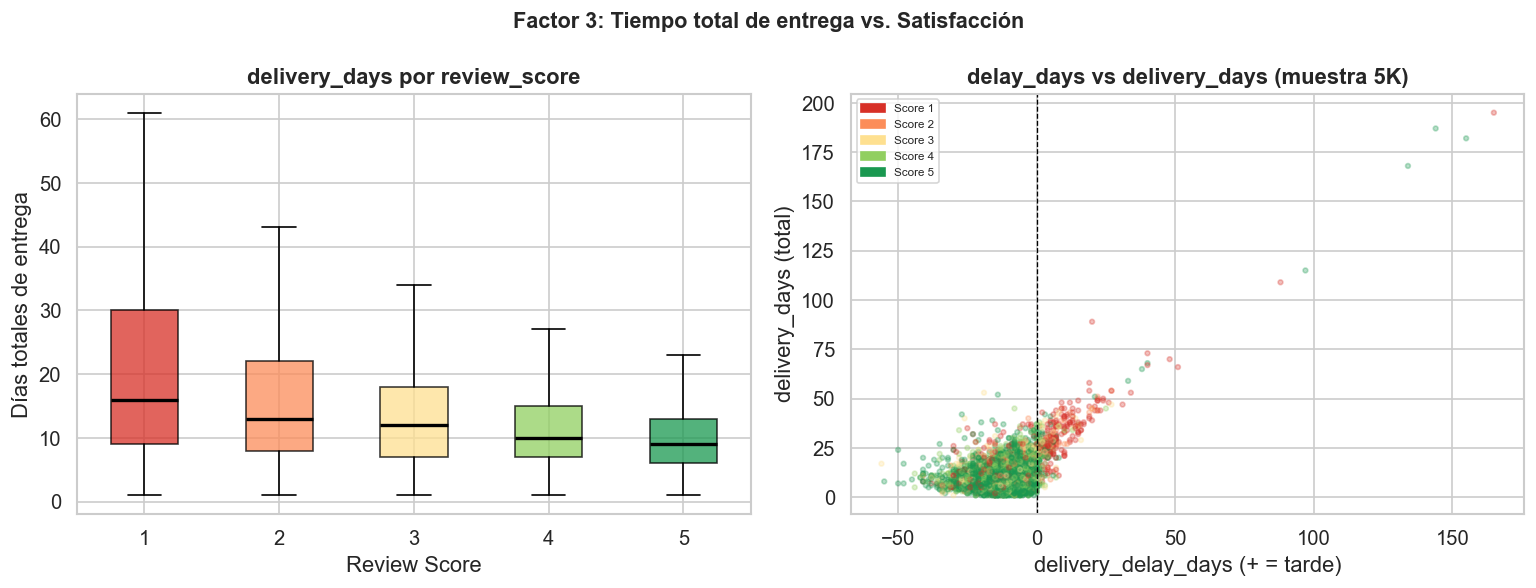

Kruskal-Wallis (delivery_days entre scores): H=6052.0, p=0.00e+00
→ Las medianas de delivery_days difieren significativamente entre grupos de score.

Media de delivery_days por score:
  Score 1: 20.9 días
  Score 2: 16.2 días
  Score 3: 13.8 días
  Score 4: 11.8 días
  Score 5: 10.2 días


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Boxplot delivery_days por score --
data_del = [df_rev[df_rev["review_score"] == s]["delivery_days"].dropna() for s in score_order]
bp3 = axes[0].boxplot(
    data_del, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp3["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("delivery_days por review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Días totales de entrega")

# -- Scatter: delivery_delay_days vs delivery_days coloreado por score --
sample = df_rev.dropna(subset=["delivery_delay_days", "delivery_days"]).sample(
    n=min(5000, len(df_rev)), random_state=42
)
scatter_colors = sample["review_score"].map(
    {1: "#d73027", 2: "#fc8d59", 3: "#fee090", 4: "#91cf60", 5: "#1a9850"}
)
axes[1].scatter(
    sample["delivery_delay_days"],
    sample["delivery_days"],
    c=scatter_colors, alpha=0.3, s=8, rasterized=True,
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("delay_days vs delivery_days (muestra 5K)", fontweight="bold")
axes[1].set_xlabel("delivery_delay_days (+ = tarde)")
axes[1].set_ylabel("delivery_days (total)")
handles = [mpatches.Patch(color=c, label=f"Score {s}")
           for s, c in zip([1,2,3,4,5], ["#d73027","#fc8d59","#fee090","#91cf60","#1a9850"])]
axes[1].legend(handles=handles, fontsize=7, markerscale=1.5)

plt.suptitle("Factor 3: Tiempo total de entrega vs. Satisfacción", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor3_delivery_days_vs_score.png", bbox_inches="tight")
plt.show()

# Test Kruskal-Wallis (no paramétrico): ¿difieren los delivery_days entre grupos de score?
groups = [df_rev[df_rev["review_score"] == s]["delivery_days"].dropna().values for s in score_order]
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis (delivery_days entre scores): H={h_stat:.1f}, p={p_kw:.2e}")
print("→ Las medianas de delivery_days difieren significativamente entre grupos de score." if p_kw < 0.05 else "")
medians = {s: round(g.mean(), 1) for s, g in zip(score_order, groups)}
print("\nMedia de delivery_days por score:")
for s, m in medians.items():
    print(f"  Score {s}: {m} días")

---
## 6. Heatmap de correlaciones cruzadas
Visualizamos las correlaciones entre todas las variables de interés para detectar multicolinealidad (dos variables que miden lo mismo) antes de un eventual modelado supervisado.

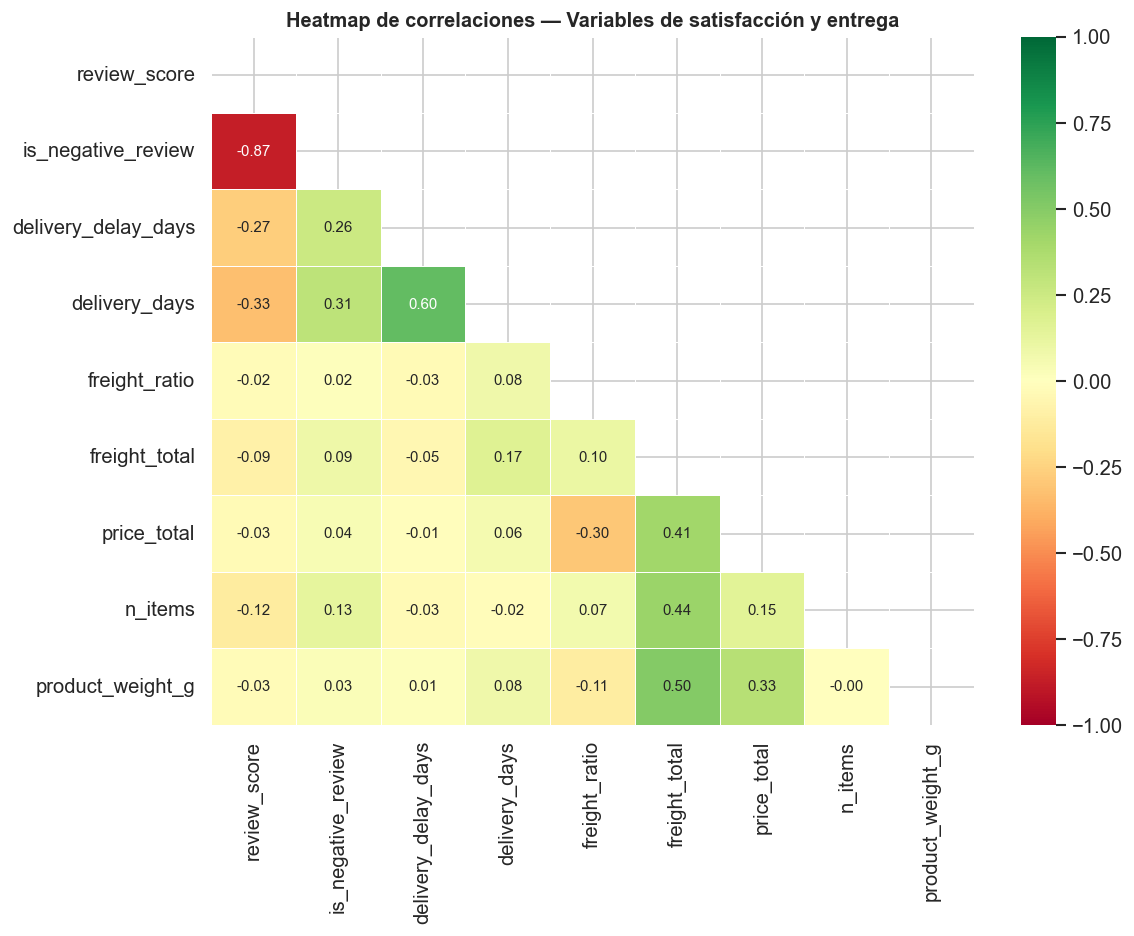

Correlación delivery_delay_days ↔ delivery_days: 0.60
→ Alta correlación: en el modelo usar solo una de las dos para evitar multicolinealidad.


In [8]:
heatmap_cols = [
    "review_score",
    "is_negative_review",
    "delivery_delay_days",
    "delivery_days",
    "freight_ratio",
    "freight_total",
    "price_total",
    "n_items",
    "product_weight_g",
]

corr_matrix = df_rev[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Heatmap de correlaciones — Variables de satisfacción y entrega",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "heatmap_negative_reviews.png", bbox_inches="tight")
plt.show()

# Nota de multicolinealidad
dd_corr = corr_matrix.loc["delivery_delay_days", "delivery_days"]
print(f"Correlación delivery_delay_days ↔ delivery_days: {dd_corr:.2f}")
print("→ Alta correlación: en el modelo usar solo una de las dos para evitar multicolinealidad.")

---
## 7. Análisis por categoría de producto
¿Hay categorías con tasas de reseña negativa sistemáticamente más altas?  
Esto puede indicar problemas logísticos específicos o productos con mala calidad percibida.

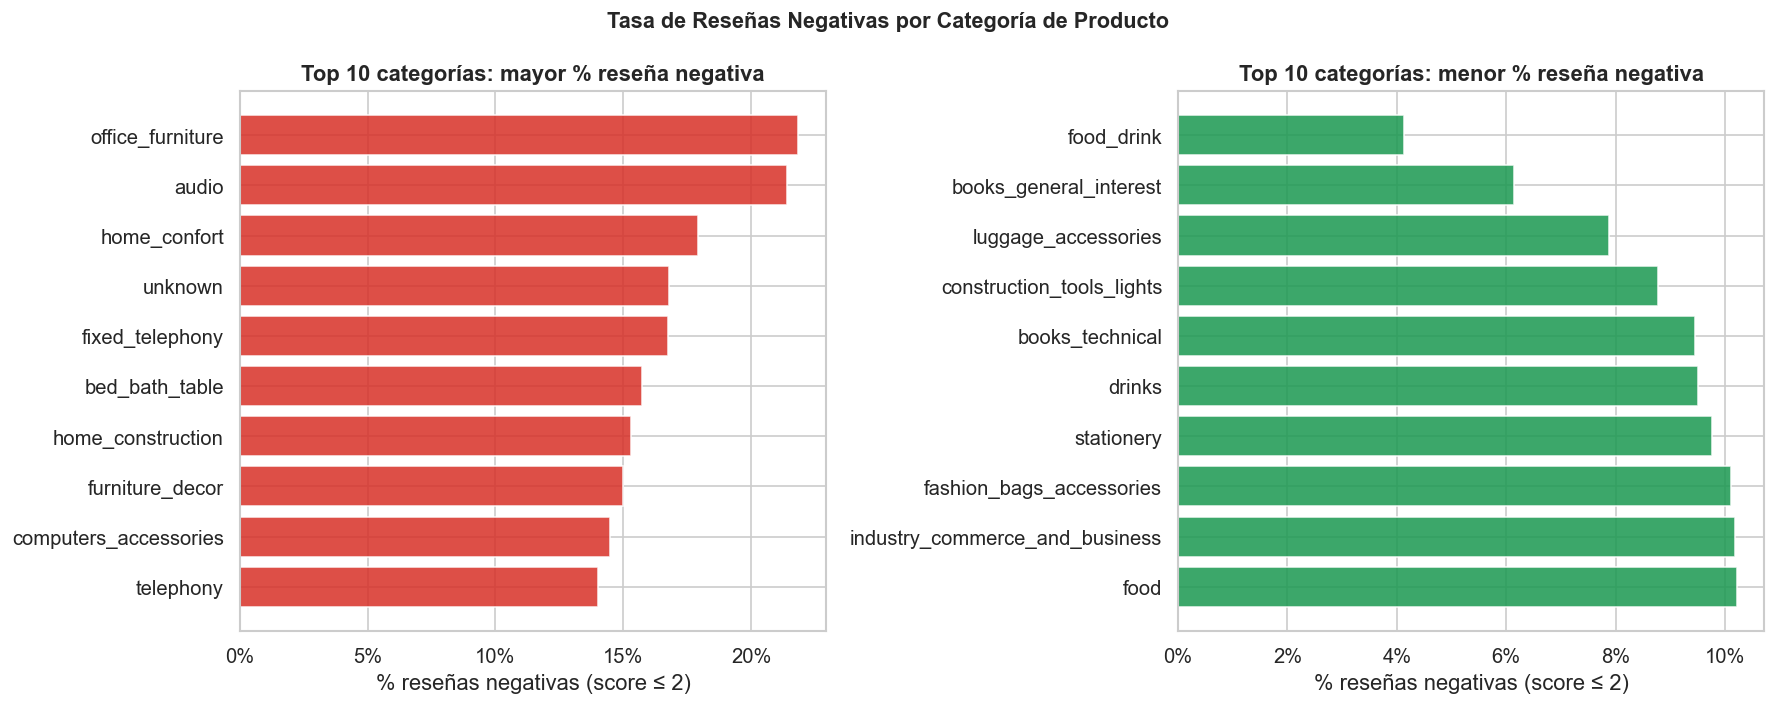


Top 5 categorías con más reseñas negativas:


,n_orders,neg_review_rate,avg_delay,avg_score
category_en,,,,
office_furniture,1236,0.218,-11.774,3.651
audio,341,0.214,-10.026,3.848
home_confort,368,0.179,-9.864,3.908
unknown,1369,0.168,-11.342,4.026
fixed_telephony,209,0.167,-14.885,3.967


In [9]:
cat_stats = (
    df_rev.groupby("category_en")
    .agg(
        n_orders        =("order_id",           "count"),
        neg_review_rate =("is_negative_review", "mean"),
        avg_delay       =("delivery_delay_days","mean"),
        avg_score       =("review_score",        "mean"),
    )
    .query("n_orders >= 200")  # mínimo 200 pedidos para significancia estadística
    .sort_values("neg_review_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top/Bottom 10 por tasa de reseña negativa
top10_neg  = cat_stats.head(10)
bot10_neg  = cat_stats.tail(10)

axes[0].barh(top10_neg.index[::-1], top10_neg["neg_review_rate"][::-1] * 100,
             color="#d73027", edgecolor="white", alpha=0.85)
axes[0].set_title("Top 10 categorías: mayor % reseña negativa", fontweight="bold")
axes[0].set_xlabel("% reseñas negativas (score ≤ 2)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1].barh(bot10_neg.index, bot10_neg["neg_review_rate"] * 100,
             color="#1a9850", edgecolor="white", alpha=0.85)
axes[1].set_title("Top 10 categorías: menor % reseña negativa", fontweight="bold")
axes[1].set_xlabel("% reseñas negativas (score ≤ 2)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Tasa de Reseñas Negativas por Categoría de Producto", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "neg_review_by_category.png", bbox_inches="tight")
plt.show()

print("\nTop 5 categorías con más reseñas negativas:")
display(cat_stats[["n_orders","neg_review_rate","avg_delay","avg_score"]].head(5).round(3))

---
## 8. Conclusión: Top 3 factores predictores de reseña negativa
**Corrección (revisión de portfolio, prioridad 2):** el ranking de abajo se deriva ahora
directamente de `corr_with_score` (Sección 2, Spearman) en vez de ser redactado a mano —
una versión anterior de este notebook declaraba `delivery_delay_days` como #1 pese a que la
propia Sección 2 imprimía `delivery_days` con mayor |correlación|. Se añade además la corrección
de Benjamini-Hochberg sobre las 6 variables candidatas testeadas, para no reportar "drivers"
sin ajustar por el número de comparaciones.

In [10]:
from statsmodels.stats.multitest import multipletests

candidate_drivers = ["delivery_days", "delivery_delay_days", "n_items",
                     "freight_total", "freight_ratio", "price_total"]
pvals = [stats.spearmanr(df_rev[c], df_rev["review_score"]).pvalue for c in candidate_drivers]
reject, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

driver_table = pd.DataFrame({
    "variable": candidate_drivers,
    "spearman_rho": [corr_with_score.get(c) for c in candidate_drivers],
    "p_value": pvals,
    "p_value_BH": p_adj,
    "significativo_tras_BH": reject,
}).assign(R2=lambda d: d["spearman_rho"] ** 2).sort_values("spearman_rho", key=abs, ascending=False)
display(driver_table.round(5))

# Top 3 real, ordenado por |rho| tras corrección por multiplicidad
top3 = driver_table.head(3)["variable"].tolist()
print(f"\nTop 3 drivers (por |Spearman rho|, tras BH): {top3}")

summary_data = {
    "Factor": [f"{i+1}. {v}" for i, v in enumerate(top3)],
    "Spearman rho": [corr_with_score.get(v) for v in top3],
    "Interpretación de negocio": [
        "Tiempo total de espera compra→entrega es el driver individual más fuerte de insatisfacción",
        "Llegar tarde vs. la fecha prometida también predice insatisfacción, pero ~84% de esas reseñas "
        "se escriben ANTES de la entrega real (ver Sección 3b): mide en parte frustración por la "
        "espera, no solo la experiencia de recibir el pedido tarde",
        "Pedidos con más ítems reciben reseñas ligeramente peores (posible fricción logística: más "
        "piezas, más riesgo de incidencia)",
    ][:len(top3)],
    "Acción recomendada": [
        "Optimizar el tiempo total del ciclo compra→entrega, no solo la precisión de la promesa",
        "Comunicación proactiva de estado del pedido mientras el cliente espera, antes de que la "
        "insatisfacción se cristalice en una reseña",
        "Revisar experiencia de empaquetado/tracking en pedidos multi-ítem",
    ][:len(top3)],
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

print("\nConcentración del impacto:")
pct_neg_late = (
    df_rev[df_rev["delivery_delay_days"] > 0]["is_negative_review"].mean() * 100
)
pct_neg_ontime = (
    df_rev[df_rev["delivery_delay_days"] <= 0]["is_negative_review"].mean() * 100
)
print(f"  % reseñas negativas cuando llega TARDE:          {pct_neg_late:.1f}%")
print(f"  % reseñas negativas cuando llega a tiempo/antes: {pct_neg_ontime:.1f}%")
print(f"  Factor multiplicador del retraso:                {pct_neg_late/pct_neg_ontime:.1f}x")
print("  (nota: esta cifra mezcla el subconjunto limpio y el contaminado por fuga temporal; "
      "ver Sección 3b para la versión ajustada)")

,variable,spearman_rho,p_value,p_value_BH,significativo_tras_BH,R2
0,delivery_days,-0.235,0.000,0.000,True,0.055
1,delivery_delay_days,-0.176,0.000,0.000,True,0.031
2,n_items,-0.107,0.000,0.000,True,0.012
3,freight_total,-0.088,0.000,0.000,True,0.008
4,freight_ratio,-0.031,0.000,0.000,True,0.001
5,price_total,-0.029,0.000,0.000,True,0.001



Top 3 drivers (por |Spearman rho|, tras BH): ['delivery_days', 'delivery_delay_days', 'n_items']


,Factor,Spearman rho,Interpretación de negocio,Acción recomendada
0,1. delivery_days,-0.234608,Tiempo total de espera compra→entrega es el driver individual más fuerte de insatisfacción,"Optimizar el tiempo total del ciclo compra→entrega, no solo la precisión de la promesa"
1,2. delivery_delay_days,-0.176503,"Llegar tarde vs. la fecha prometida también predice insatisfacción, pero ~84% de esas reseñas se escriben ANTES de la entrega real (ver Sección 3b): mide en parte frustración por la espera, no solo la experiencia de recibir el pedido tarde","Comunicación proactiva de estado del pedido mientras el cliente espera, antes de que la insatisfacción se cristalice en una reseña"
2,3. n_items,-0.107332,"Pedidos con más ítems reciben reseñas ligeramente peores (posible fricción logística: más piezas, más riesgo de incidencia)",Revisar experiencia de empaquetado/tracking en pedidos multi-ítem



Concentración del impacto:
  % reseñas negativas cuando llega TARDE:          62.4%
  % reseñas negativas cuando llega a tiempo/antes: 9.3%
  Factor multiplicador del retraso:                6.7x
  (nota: esta cifra mezcla el subconjunto limpio y el contaminado por fuga temporal; ver Sección 3b para la versión ajustada)


---
## 9. Resumen ejecutivo

*(Corrección de portfolio: esta tabla y el `freight_ratio` como driver #3 de una versión anterior
de este notebook no se sostenían — ver Secciones 2, 3b, 4 y 8. Los valores de abajo se leen de
`driver_table` calculada arriba, no se redactan a mano.)*

In [11]:
ranking_md = "| Ranking | Factor | Spearman rho | p (BH) | Evidencia |\n|---|---|---|---|---|\n"
notas = {
    "delivery_days": "Mayor |rho| de todas las variables candidatas; Kruskal-Wallis significativo por score (Sección 5)",
    "delivery_delay_days": "Mann-Whitney U significativo (Sección 3); ~84% de las reseñas de pedidos tardíos se escriben antes de la entrega real (Sección 3b) -- el efecto post-entrega, medido en el subconjunto limpio, es varias veces más débil",
    "n_items": "Sustituye a freight_ratio (Spearman rho no monótono, R²≈0.001, ver Sección 4) como 3er driver",
}
for _, row in driver_table.head(3).iterrows():
    ranking_md += (f"| **#{list(driver_table.head(3)['variable']).index(row['variable'])+1}** "
                   f"| `{row['variable']}` | {row['spearman_rho']:+.3f} | {row['p_value_BH']:.1e} "
                   f"| {notas.get(row['variable'], '')} |\n")
from IPython.display import Markdown
display(Markdown(ranking_md))

| Ranking | Factor | Spearman rho | p (BH) | Evidencia |
|---|---|---|---|---|
| **#1** | `delivery_days` | -0.235 | 0.0e+00 | Mayor |rho| de todas las variables candidatas; Kruskal-Wallis significativo por score (Sección 5) |
| **#2** | `delivery_delay_days` | -0.177 | 0.0e+00 | Mann-Whitney U significativo (Sección 3); ~84% de las reseñas de pedidos tardíos se escriben antes de la entrega real (Sección 3b) -- el efecto post-entrega, medido en el subconjunto limpio, es varias veces más débil |
| **#3** | `n_items` | -0.107 | 4.1e-243 | Sustituye a freight_ratio (Spearman rho no monótono, R²≈0.001, ver Sección 4) como 3er driver |


**Implicación para el modelo (Fase 5):** `delivery_delay_days` y `delivery_days` tienen alta correlación entre sí (ver heatmap, Sección 6) — usar solo una de las dos como predictor principal para evitar multicolinealidad. `freight_ratio` queda descartado como driver (Sección 4); `n_items` aporta información complementaria.

### Próximos pasos
- Notebook 04: Segmentación RFM de clientes
- Notebook 05: Modelo predictivo de reseña negativa (Logistic Regression / Random Forest)